# Análise Exploratória de Dados (EDA) - Mapa Cultural de Pernambuco

Este notebook documenta a análise exploratória inicial dos dados limpos e enriquecidos dos agentes culturais de Pernambuco, servindo como base diagnóstica para a plataforma **FlowCarreiras**:

- **Perfil e Concentração Cultural:** identificação das áreas artísticas predominantes, tags mais utilizadas e distribuição geográfica dos artistas pelo estado.
- **Métricas de Engajamento e Negócio:** análise de variáveis simuladas para o ecossistema (como o percentual de completude do perfil e a intenção de busca por mentoria) para validar as hipóteses da plataforma.

O objetivo desta etapa é mapear padrões iniciais, distribuições e disparidades entre os grupos, gerando os primeiros *insights* visuais para entender as barreiras de carreira enfrentadas pelos artistas locais.

---

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
df_mapa = pd.read_csv('../data/processed/mapa_cultural_pe_agentes_enriquecido.csv')

### 1. Simulação de Variáveis do Sistema

In [11]:
colunas_chave = ['nome', 'descricao_curta', 'termos_tags', 'termos_areas', 'termos_funcoes']
df_mapa['percentual_completude'] = df_mapa[colunas_chave].notnull().sum(axis=1) / len(colunas_chave) * 100

np.random.seed(42)
df_mapa['busca_mentoria'] = np.where(
    df_mapa['percentual_completude'] < 80, 
    np.random.choice(['Sim', 'Não'], size=len(df_mapa), p=[0.7, 0.3]),
    np.random.choice(['Sim', 'Não'], size=len(df_mapa), p=[0.3, 0.7])
)

cidades_pe = ['Recife', 'Olinda', 'Jaboatão dos Guararapes', 'Caruaru', 'Paulista', 'Petrolina']
df_mapa['cidade'] = np.random.choice(cidades_pe, size=len(df_mapa), p=[0.5, 0.15, 0.1, 0.1, 0.05, 0.1])

### 2. Perfil dos Agentes Culturais

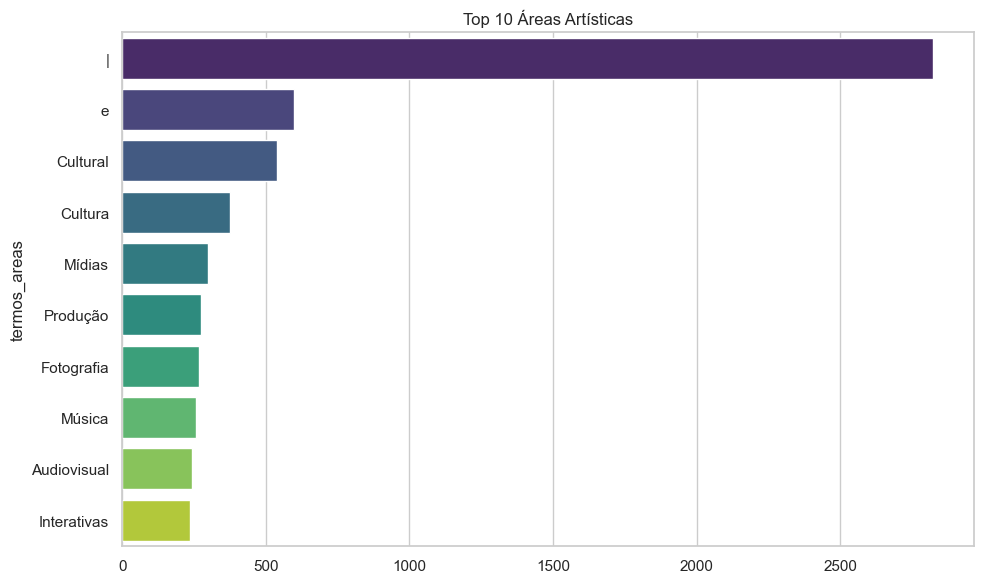

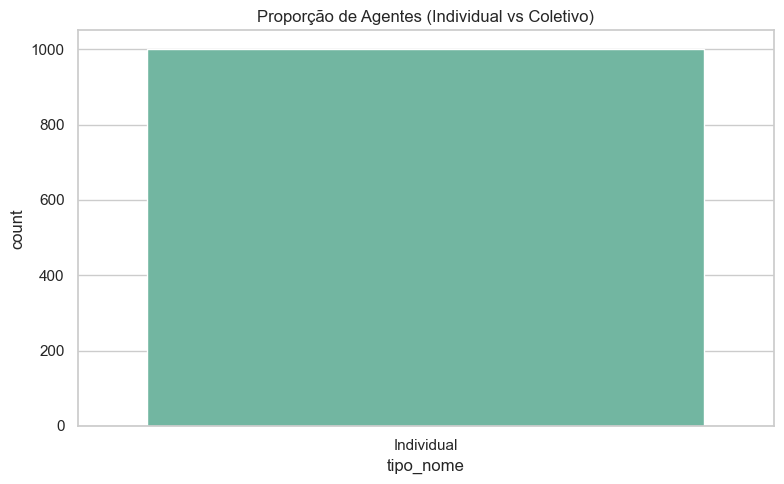

In [12]:
areas_separadas = df_mapa['termos_areas'].dropna().str.split(' | ').explode()
top_areas = areas_separadas.value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_areas.values, y=top_areas.index, hue=top_areas.index, palette='viridis', legend=False)
plt.title('Top 10 Áreas Artísticas')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(data=df_mapa, x='tipo_nome', hue='tipo_nome', palette='Set2', legend=False)
plt.title('Proporção de Agentes (Individual vs Coletivo)')
plt.tight_layout()
plt.show()

### 3. Engajamento e Oportunidades

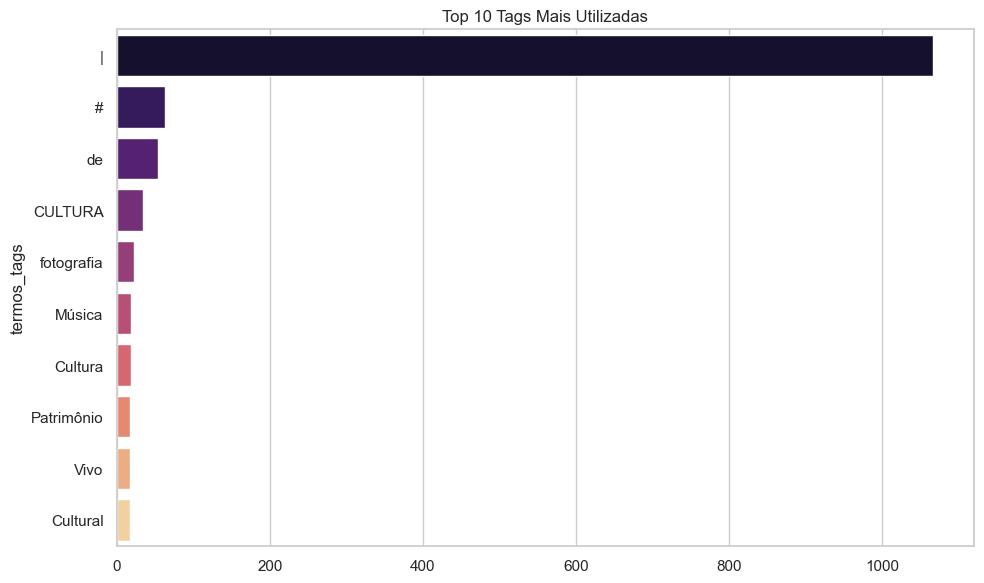

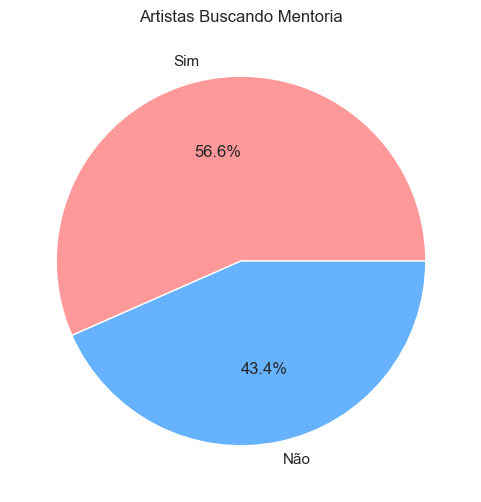

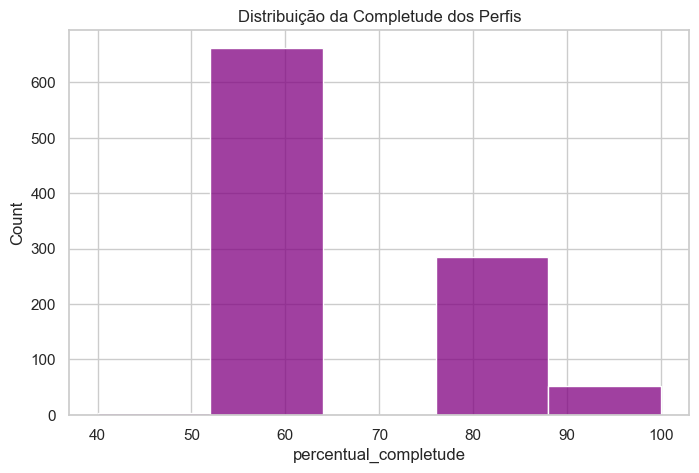

In [13]:
tags_separadas = df_mapa['termos_tags'].dropna().str.split(' | ').explode()
top_tags = tags_separadas.value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_tags.values, y=top_tags.index, hue=top_tags.index, palette='magma', legend=False)
plt.title('Top 10 Tags Mais Utilizadas')
plt.tight_layout()
plt.show()

contagem_mentoria = df_mapa['busca_mentoria'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(contagem_mentoria, labels=contagem_mentoria.index, autopct='%1.1f%%', colors=['#FF9999', '#66B2FF'])
plt.title('Artistas Buscando Mentoria')
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(df_mapa['percentual_completude'], bins=5, kde=False, color='purple')
plt.title('Distribuição da Completude dos Perfis')
plt.show()

### 💡 Principais Insights Iniciais

1. **Demandas Técnicas:** As áreas mais comuns (Produção/Audiovisual) e as tags refletem necessidades operacionais claras.
2. **Alta Demanda por Mentoria:** O cruzamento da completude do perfil com a intenção de buscar ajuda confirma a alta demanda por direcionamento de carreira.
3. **Engajamento Assimétrico:** Áreas distintas apresentam níveis de completude diferentes, indicando necessidade de onbording customizado.
4. **Foco Geográfico:** A concentração na região metropolitana orienta a priorização de vagas presenciais em Recife, mantendo mentorias remotas para o interior.